## Suivi Par MPOUAVOULI Rayde Prosperin
## Chapitre 5 : Réaliser un backesting et mesurer la performance

##### Le **Backtesting** consiste à tester une stratégie d'investissement sur les **données historiques** pour évaluer sa performance passée. Celà permet de :
##### Vérifier la robustesse d'une stratégie
##### Ajuster les paramètres sans risque
##### Comprendre la dynamique du marché

##### Ce chapitre a pour objectifs de : 
##### Comprendre le principe du backetesting et son interet en finance
##### Implémenter une stratégie de trading simple en python(ex: croisement de moyennes mobiles)
##### Manipuler des outils python adaptés à l'analyse financière : pandas, matplotlib, yfinance, backtrader

### 1. **Implementer une strategie simple**

##### Une strategie de **croisement de moyennes mobiles** est l'une des méthodes les plus populaires et accessibles en trading algorithmique.

### Principe
##### Cette stratégie repose sur la comparaison de deux moyennes mobiles:
##### -**SMA Courte** (ex :20 jours) : réagit plus viteaux variations du marché
##### -**SMA longue** (ex: 50 jours) : filtre mouvements de CT et donneune tendance plus stable

### **Règles de la strategie**
##### -**Signal court**: lorsque la SMA est courte **croise au-dessus** de la SMA longue ce qui entraine un début d'unetendance haussière probable
##### -**Signal de vente** : lorsque la SMA courte **croise en dessous** de la SMA longue ce qui entraine un debut d'une tendance bassière probable

##### Cette stratégie permet de suivre la tendance du marché sans tenter de prédire les retournements.
##### L'objectif est de **laisser courir les gains** et de **limiter les pertes** en réagissant uniquement aux signaux donnés par les croisements.

### **Avantages**
##### - Facile à comprendre et à coder
##### - Adaptable à n'importe quel actif
##### - Fonctionne bien dans les marchés en tendance

### **Limites**
##### - Moins performant dans les marchés en range(sans tendance)
##### - Peut générer des taux signaux(bruit du marché)

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Télécharger les données Apple
df = yf.download('AAPL', start='2020-01-01', end='2024-12-31')


# Ça fonctionne même si yfinance renvoie un DataFrame multi-niveaux
df.columns = df.columns.droplevel('Ticker')
df.dropna(inplace=True)
df.head()

C:\Users\Visiteur\AppData\Local\Temp\ipykernel_46512\3251430220.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', start='2020-01-01', end='2024-12-31')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,72.538513,72.598892,71.292304,71.545890,135480400
2020-01-03,71.833282,72.594048,71.608677,71.765659,146322800
2020-01-06,72.405678,72.444321,70.703012,70.954188,118387200
2020-01-07,72.065163,72.671356,71.845385,72.415353,108872000
2020-01-08,73.224419,73.526310,71.768094,71.768094,132079200


In [17]:
# 2. Calcul des moyennes mobiles
df['SMA20'] = df['Close'].rolling(window=20).mean()
df['SMA50'] = df['Close'].rolling(window=50).mean()

In [3]:
#3. Détection des signaux
df['Signal'] = 0
df.loc[df['SMA20'] > df['SMA50'], 'Signal'] = 1
df.loc[df['SMA20'] < df['SMA50'], 'Signal'] = 0
df['Position'] = df['Signal'].diff()

In [4]:
df[['Close', 'SMA20', 'SMA50', 'Signal', 'Position']].tail()

Price,Close,SMA20,SMA50,Signal,Position
Date,,,,,
2024-12-23,254.367035,244.160252,234.447662,1,0.0
2024-12-24,257.286652,245.422272,234.988824,1,0.0
2024-12-26,258.103729,246.616033,235.495565,1,0.0
2024-12-27,254.685883,247.645379,235.975157,1,0.0
2024-12-30,251.307877,248.386249,236.379823,1,0.0


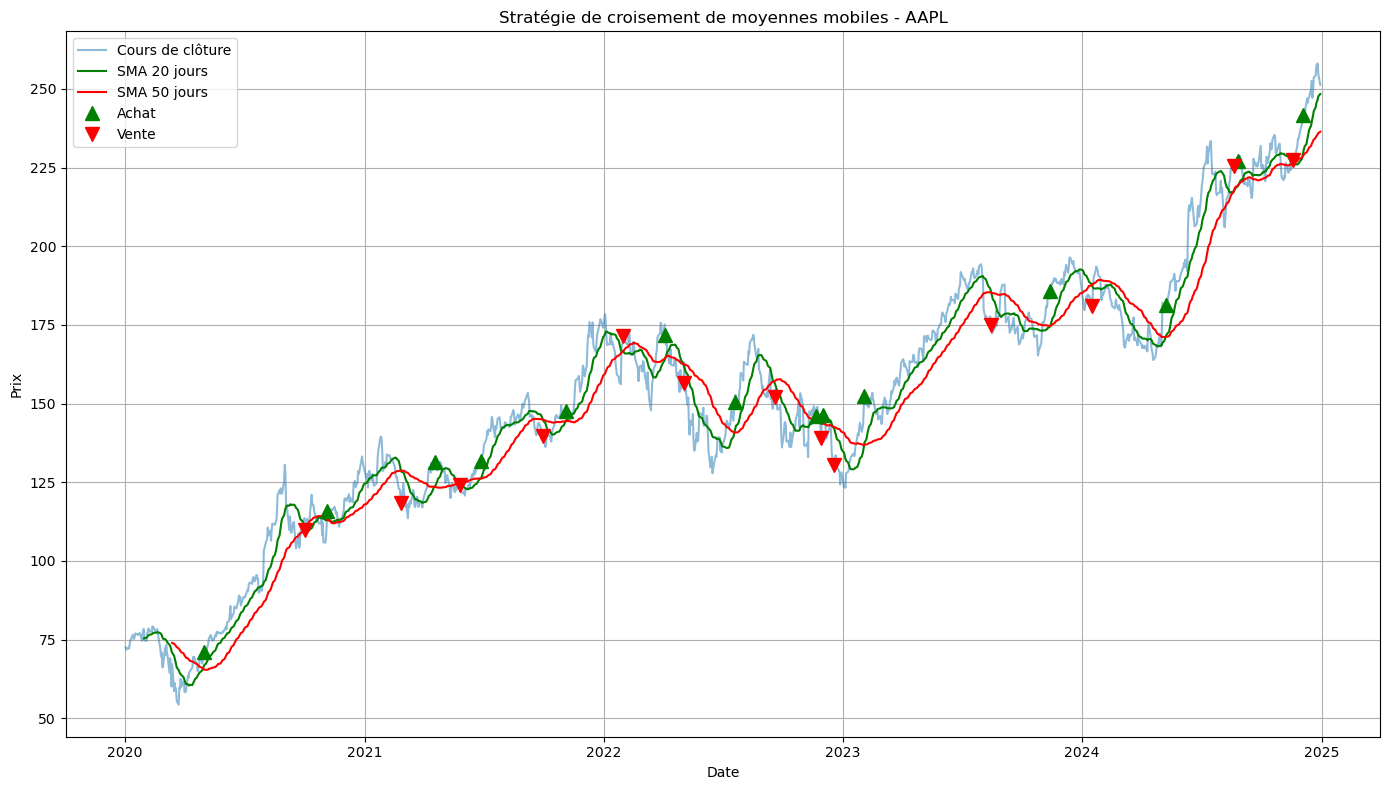

In [5]:
# 4. Tracer le graphique
plt.figure(figsize=(14, 8))
plt.plot(df['Close'], label='Cours de clôture', alpha=0.5)
plt.plot(df['SMA20'], label='SMA 20 jours', color='green')
plt.plot(df['SMA50'], label='SMA 50 jours', color='red')

# Points d'achat
plt.plot(df[df['Position'] == 1].index, df['Close'][df['Position'] == 1], '^', color='green', markersize=10, label='Achat')

# Points de vente
plt.plot(df[df['Position'] == -1].index, df['Close'][df['Position'] == -1], 'v', color='red', markersize=10, label='Vente')

plt.title("Stratégie de croisement de moyennes mobiles - AAPL")
plt.xlabel("Date")
plt.ylabel("Prix")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### - **Stimuler les transactions**

##### **Backtrader** est une des bibliothèques python les plus puissantes pour :
##### - Créer des **stratégies personnalisées**
##### - Définir **les ordres**(buy/sell)
##### - Obtenir des **statistiques détaillées**(rendement, drawdown, Winrate, etc.)

### - **Comment fonctionne une simulation Backtrader**
##### 1 - Charger les données(yfinance, csv ou API)
##### 2 - Définir la **stratégie** (ex: croisement des moyennes mobiles)
##### 3 - Initialiser le **portefeuille virtuel** avec un 
##### 4 - Lancer le**Backtest**
##### 5 - Observerles résultats :
#####     Rendement net
#####     Pertes maximales (drawdown)
#####     Ratio de trades gagnants
#####     Nombre de transactions

### Interprétation des résultats
##### - **Courbe de capital(equity curve)** : doit etre croissante et régulière
##### - **Signal d'achat vs performance réelle** : valide ou invalide la stratégie
##### - **Drawdown** : mesure la **perte maximale** en cas de mauvaise passe(à surveiller)

### **Attention aux illusions de performance**
##### Meme si une stratégie fonctionne bien sur le passé, celà ne garantit **pas sa performance future**

##### - les données peuvent etre **sur-optimisées** (overfiting)
##### - le marché peut **changer de régime**
##### - Des **frais de transaction** ou des tendances peuvent modifier les résultats

In [6]:
pip install backtrader

Note: you may need to restart the kernel to use updated packages.


In [7]:
import backtrader as bt
# On ne garde que les colonnes nécessaires pour le trading
data = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
data.dropna(inplace=True)  # On supprime les lignes incomplètes

# Backtrader préfère les noms de colonnes en minuscules
data.columns = [col.lower() for col in data.columns]

# On remet l'index 'Date' sous forme de colonne pour Backtrader
data.reset_index(inplace=True)
data.reset_index(inplace=True)
data.head()

,index,Date,open,high,low,close,volume
0,0,2020-01-02,71.545890,72.598892,71.292304,72.538513,135480400
1,1,2020-01-03,71.765659,72.594048,71.608677,71.833282,146322800
2,2,2020-01-06,70.954188,72.444321,70.703012,72.405678,118387200
3,3,2020-01-07,72.415353,72.671356,71.845385,72.065163,108872000
4,4,2020-01-08,71.768094,73.526310,71.768094,73.224419,132079200


In [18]:
# ----------------------------
#  2. Créer un "Data Feed" pour Backtrader
# ----------------------------

# Un "Data Feed", c’est un connecteur entre tes données pandas et Backtrader.
# Il lui explique comment lire la colonne 'Date', 'Open', etc. depuis le DataFrame.
class PandasData(bt.feeds.PandasData):
    params = (
        ('datetime', 'Date'),        # Indique la colonne utilisée comme date
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),        # Pas utilisé ici, on le désactive avec -1
    )

# 📈 3. Créer la stratégie de croisement de moyennes mobiles
# ----------------------------
class SMACrossStrategy(bt.Strategy):
    params = (
        ('sma_short', 20),  # période pour la moyenne mobile courte
        ('sma_long', 50),   # période pour la moyenne mobile longue
    )

    def __init__(self):
        # Calcul des deux moyennes mobiles
        self.sma_short = bt.ind.SMA(period=self.params.sma_short)
        self.sma_long = bt.ind.SMA(period=self.params.sma_long)

        # Détecter les croisements entre les deux SMA (cross up ou down)
        self.crossover = bt.ind.CrossOver(self.sma_short, self.sma_long)

    def next(self):
        # Cette méthode s’exécute à chaque nouvelle bougie (jour)
        if not self.position:
            # Si on n’a pas de position (ni achat, ni vente)
            if self.crossover > 0:
                self.buy()  #  Croisement haussier → on achète
        elif self.crossover < 0:
            self.sell()  #  Croisement baissier → on revend tout

# 4. Initialiser Backtrader et ajouter notre stratégie
cerebro = bt.Cerebro()  # Le moteur de backtest de Backtrader
cerebro.addstrategy(SMACrossStrategy)  # Ajout de notre stratégie dans le moteur

# Création du "data feed" à partir du DataFrame qu'on a préparé
data_feed = PandasData(dataname=data)

# Ajout des données au moteur de simulation
cerebro.adddata(data_feed)

# Définir le capital initial
cerebro.broker.set_cash(10000.0)

# Affichage du capital avant simulation
print(f" Capital initial : {cerebro.broker.getvalue():.2f} $")

 Capital initial : 10000.00 $


In [19]:
# 5. Exécuter la simulation
cerebro.run()

# Affichage du capital après simulation
print(f" Capital final : {cerebro.broker.getvalue():.2f} $")

 Capital final : 10110.30 $


In [12]:
# Capital initial utilisé dans cerebro
capital_initial = 10000.0
cerebro.broker.set_cash(capital_initial)

# Lancer le backtest
cerebro.run()

# Récupérer le capital final
capital_final = cerebro.broker.getvalue()

# Calcul du rendement en pourcentage
rendement = (capital_final - capital_initial) / capital_initial * 100

# Affichage propre
print(f"Capital initial : {capital_initial:.2f} $")
print(f"Capital final : {capital_final:.2f} $")
print(f"Rendement total : {rendement:.2f} %")

Capital initial : 10000.00 $
Capital final : 10110.30 $
Rendement total : 1.10 %


### **Mesurer la performance de la stratégie**
##### Après avoir simulé une stratégie de trading (comme le croisement de moyennes mobiles), il est essentiel d'évaluer sa performance. Voici trois indicateurs fondamentaux à analyser :

##### 1. **Capital final**
###### Il s'agit de la valeur du portefeuille à la fin du backtest, en tenant compte :

##### - du cash restant,
##### et de la valeur des positions en cours.
##### - Cela permet de savoir si la stratégie a généré un gain ou une perte.

##### 2. **Rendement total (%)**
##### C’est la variation du capital exprimée en pourcentage par rapport au capital initial.

##### Formule :

##### Rendement (%) = [(Capital final - Capital initial) / Capital initial] × 100
##### Un rendement positif indique une stratégie gagnante. Un rendement négatif signifie une perte nette.

##### **3. Drawdown maximal**
##### Le drawdown maximal mesure la plus forte baisse du portefeuille depuis un sommet. C’est un indicateur de risque.

##### Formule :

##### Drawdown = (Sommet du capital - creux suivant) / Sommet du capital
##### Une stratégie peut être rentable, mais risquée si le drawdown est élevé.

##### Autres indicateurs possibles
##### - Taux de réussite des trades
##### -Nombre de trades gagnants/perdants
##### -Ratio gain/perte
##### -Durée moyenne des positions
##### -Sharpe Ratio (rendement ajusté au risque)

### **Conclusion**
##### - Une bonne stratégie ne doit pas seulement être rentable, mais aussi stable et maîtrisée en termes de risque.

In [14]:
# Récupérer le capital initial et final
capital_initial = 1000  # Même valeur que dans cerebro.broker.set_cash()
capital_final = cerebro.broker.getvalue()

# Calcul du rendement total
rendement = (capital_final - capital_initial) / capital_initial * 100

# Affichage des résultats
print(f"Capital initial : {capital_initial:.2f} $")
print(f"Capital final   : {capital_final:.2f} $")
print(f"Rendement total : {rendement:.2f} %")


Capital initial : 1000.00 $
Capital final   : 10110.30 $
Rendement total : 911.03 %


In [16]:
import backtrader as bt

# --- 1. Adapter les données pour Backtrader ---
class PandasData(bt.feeds.PandasData):
    params = (
        ('datetime', 'Date'),
        ('open', 'open'),
        ('high', 'high'),
        ('low', 'low'),
        ('close', 'close'),
        ('volume', 'volume'),
        ('openinterest', -1),
    )


# --- 2. Stratégie SMA croisée enrichie ---
class SMACrossStrategy(bt.Strategy):
    def __init__(self):
        # Définition des deux moyennes mobiles
        self.sma_short = bt.ind.SMA(period=20)
        self.sma_long = bt.ind.SMA(period=50)
        self.crossover = bt.ind.CrossOver(self.sma_short, self.sma_long)

        # Variables de suivi
        self.portfolio_values = []
        self.trades = []
        self.buy_price = None

    def next(self):
        # Sauvegarde la valeur du portefeuille à chaque step
        self.portfolio_values.append(self.broker.getvalue())

        # --- Logique de trading ---
        if not self.position:  # Si on n’a pas de position ouverte
            if self.crossover > 0:
                self.buy_price = self.data.close[0]
                self.buy()
        elif self.crossover < 0:  # Si croisement baissier
            sell_price = self.data.close[0]
            gain = sell_price - self.buy_price
            self.trades.append(gain)
            self.sell()

    def stop(self):
        # --- Calcul des performances ---
        capital_initial = self.broker.startingcash
        capital_final = self.broker.getvalue()
        rendement = (capital_final - capital_initial) / capital_initial * 100

        # --- Calcul du drawdown maximum ---
        peak = self.portfolio_values[0] if self.portfolio_values else 0
        max_dd = 0
        for val in self.portfolio_values:
            if val > peak:
                peak = val
            dd = (peak - val) / peak
            if dd > max_dd:
                max_dd = dd

        # --- Statistiques sur les trades ---
        total_trades = len(self.trades)
        winning_trades = len([t for t in self.trades if t > 0])
        losing_trades = total_trades - winning_trades
        win_rate = (winning_trades / total_trades) * 100 if total_trades > 0 else 0
        avg_gain = sum(self.trades) / total_trades if total_trades > 0 else 0
        gains = [t for t in self.trades if t > 0]
        losses = [t for t in self.trades if t < 0]
        avg_win = sum(gains) / len(gains) if gains else 0
        avg_loss = abs(sum(losses) / len(losses)) if losses else 0
        gain_loss_ratio = avg_win / avg_loss if avg_loss > 0 else 0

        # --- Affichage ---
        print("\n------ Résultats de la stratégie ------")
        print(f"Capital initial : {capital_initial:.2f} $")
        print(f"Capital final   : {capital_final:.2f} $")
        print(f"Rendement total : {rendement:.2f} %")
        print(f"Drawdown maximal : {max_dd * 100:.2f} %")
        print(f"Nombre de trades : {total_trades}")
        print(f"Trades gagnants  : {winning_trades}")
        print(f"Trades perdants  : {losing_trades}")
        print(f"Taux de réussite : {win_rate:.2f} %")
        print(f"Gain moyen / trade : {avg_gain:.2f}")
        print(f"Ratio gain/perte : {gain_loss_ratio:.2f}")


# --- 3. Backtest ---
cerebro = bt.Cerebro()
cerebro.addstrategy(SMACrossStrategy)
cerebro.adddata(PandasData(dataname=data))  # <-- ton DataFrame
cerebro.broker.setcash(1000.0)
cerebro.startingcash = 1000.0

# Exécution du backtest
cerebro.run()

# Affichage graphique
cerebro.plot(style='candlestick', volume=True)



------ Résultats de la stratégie ------
Capital initial : 1000.00 $
Capital final   : 1110.30 $
Rendement total : 11.03 %
Drawdown maximal : 4.57 %
Nombre de trades : 13
Trades gagnants  : 8
Trades perdants  : 5
Taux de réussite : 61.54 %
Gain moyen / trade : 7.03
Ratio gain/perte : 1.77


<IPython.core.display.Javascript object>

[[<Figure size 640x480 with 5 Axes>]]